# WaNet (noise mode) — Warping-based Backdoor Attack — MobileNetV3-Large (BelgiumTSC)

**Threat model: data-poisoning / supply-chain.** An attacker injects a small fraction of poisoned samples; the model behaves normally on clean inputs but flips to a chosen target class whenever the trigger is present.

**Trigger = WaNet (Nguyen & Tran, ICLR 2021):** instead of *adding* a pattern, WaNet applies a smooth, fixed image **warp** (an elastic field that subtly displaces pixels). This is the *global structural* counterpart to the *localized additive* BadNets patch (Gu et al. 2017) and the *global additive* Blended trigger (Chen et al. 2017) — three qualitatively different trigger families in one benchmark.

The warp mechanic below is **ported verbatim from the authors' official code** (VinAIResearch/Warping-based_Backdoor_Attack-release, `train.py`) — control-grid construction, mean-abs normalization, bicubic upsample, and `grid_sample` settings are exactly theirs (only the field is seeded for reproducibility). **This notebook trains WaNet's NOISE MODE** — the authors' fair configuration: each training batch is split clean / attack(warp→target) / noise(warp+random→true-label) in the loop (see the noise-mode cell). Defenses are future work.

**The two metrics:** **Clean Accuracy (CA)** (stealth of benign behavior) and **Attack Success Rate (ASR)** (fraction of *warped* non-target test images classified as the target). At 0% poisoning ASR should be near-chance — the control proving the warp only works *because of poisoning*.

## Experimental scope — v1 (WaNet native config)
WaNet runs in its **native per-batch noise-mode** configuration (`pc = PC_ATTACK`, `cross_ratio = PC_NOISE` from the authors). It has **no dataset-level poison rate** — unlike BadNets/Blended, there is **no poison-rate sweep**; this is a deliberate per-attack-best choice for the scenario database. v1 produces: a **native-config headline** (CA/ASR mean±std at `s = WARP_S`, multi-seed) and a **Block B strength (`s`) sweep** at the native pc (stealth-vs-potency). Block C (a future 2-D `s × pc` grid) is stubbed.

## Configuration & imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, models
from torchvision.models import MobileNet_V3_Large_Weights
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
import numpy as np
from PIL import Image
import os, json, random
import matplotlib.pyplot as plt

# ── WaNet configuration (cell 0) ────────────────────────────────────────
NUM_CLASSES   = 62
TARGET_LABEL  = 0            # all-to-one: warped images -> class 0 (authors' all2one)
# WaNet has NO dataset-level poison rate — it poisons PER BATCH (pc/cross_ratio). We run it the
# authors' native way; there is no POISON_RATES sweep here (unlike BadNets/Blended). Deliberate.

IMG_SIZE  = 224
WARP_K    = 4         # control-grid size (k x k); FIXED, never swept (analog of trigger key)
WARP_SEED = 1234      # seeds the fixed ATTACK warp field; FIXED FOREVER, never swept
WARP_S    = 5         # native operating point: s=5 -> ~2.6px mean displacement at 224px, the
                      # genuinely SUBTLE choice from the calibration figure (s=10/5.1px is already
                      # visibly distorted). The official warp divides by input_height, so small s
                      # is sub-pixel at 224px — hence the rescaled grid. If ASR is weak at s=5 that
                      # is a FINDING (imperceptible warp too weak at high res), not a bug.
WARP_S_GRID = [2, 5, 10, 20, 40]   # Block B strength sweep at the native pc. Spans invisible (2)
                                   # -> subtle (5, the WARP_S operating point) -> visible (20) ->
                                   # distorted (40). (s=80 ~37px was a melted blob; dropped.)
GRID_RESCALE = 1      # opt.grid_rescale default in the official config.py

# ── Noise-mode knobs (authors' native per-batch config; from the cloned config.py) ──
PC_ATTACK = 0.1       # opt.pc default: fraction of EACH batch warped->TARGET (attack set)
PC_NOISE  = 2.0       # opt.cross_ratio default: noise-set size = int(num_bd * cross_ratio)
                      # i.e. num_cross = int(num_bd * 2). The noise warp's random component is
                      # RE-SAMPLED per batch (the point of noise mode); only the ATTACK warp
                      # field (noise_grid) is the fixed trigger. Applies to the WHOLE batch.

SEED          = 42
SEEDS         = [42, 123, 7]    # multi-seed for the native-config headline (CA/ASR mean +/- std)

MODEL_NAME  = 'mobilenetv3'
MODEL_TITLE = 'MobileNetV3-Large'
DS_TITLE    = 'BelgiumTSC'
DS_SHORT    = 'bel'
CKPT_TAG    = '_bel'   # checkpoint name infix ('' for gtsrb, '_bel' for bel)
BATCH_SIZE  = 64
NUM_EPOCHS  = 30
MODELS_DIR  = 'models'   # all trained checkpoints (.pth) are saved here

DATA_DIR   = 'dataset'
# NOTE: confirm TRAIN_DIR matches your clean bel training notebook's actual path.
TRAIN_DIR  = os.path.join(DATA_DIR, 'BelgiumTSC_Training', 'Training')
TEST_DIR   = os.path.join(DATA_DIR, 'BelgiumTSC_Testing', 'Testing')
VAL_SPLIT  = 0.2

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
print(f'{MODEL_TITLE} | {DS_TITLE} | classes={NUM_CLASSES} | epochs={NUM_EPOCHS} | batch={BATCH_SIZE}')
print(f'WaNet noise mode: s={WARP_S}, s grid={WARP_S_GRID}, pc={PC_ATTACK}, cross_ratio={PC_NOISE}, k={WARP_K}, warp_seed={WARP_SEED}')
os.makedirs(MODELS_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Using device: cuda
MobileNetV3-Large | BelgiumTSC | classes=62 | epochs=30 | batch=64
WaNet noise mode: s=5, s grid=[2, 5, 10, 20, 40], pc=0.1, cross_ratio=2.0, k=4, warp_seed=1234


## Transforms — split so the warp is applied in pixel `[0,1]` space
Same augmentation/resize as the clean training notebook, but the final `Normalize` is **factored out**. The dataset wrappers produce a `[0,1]` tensor, **warp** it there, and normalize **last** — the warp operates on real pixels (`grid_sample`), exactly as in the official code.

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)   # applied AFTER the warp

train_transform_01 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
])
val_test_transform_01 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)
print('Transforms defined (warp applied in [0,1] pixel space, normalize applied last).')

Transforms defined (warp applied in [0,1] pixel space, normalize applied last).


## Datasets — reused bel `NumericImageFolder` (ImageFolder test set, no CSV)
Same loader as the clean bel training notebook: folders are zero-padded `'00000'..'00061'`, so the mapping check uses `'00010' -> 10`. The test set is a **separate `Testing/` ImageFolder** (not a CSV), loaded with `allow_empty=True`. Same 80/20 train/val split (seed=42) — on bel this reproduces ~3660 train / ~915 val, with the separate Testing folder (~2520) as the clean test set. These carry the **`[0,1]`-space** transforms (normalize is added later by the wrappers).

In [3]:
class NumericImageFolder(torchvision.datasets.ImageFolder):
    """Sorts class folders by integer value. BelgiumTSC folders are zero-padded
    '00000'..'00061'; os.scandir + is_dir skips non-directory entries (Readme.txt)."""
    def find_classes(self, directory):
        classes = sorted(
            (e.name for e in os.scandir(directory) if e.is_dir()),
            key=lambda x: int(x)
        )
        class_to_idx = {cls: int(cls) for cls in classes}
        return classes, class_to_idx

full_train_dataset = NumericImageFolder(TRAIN_DIR, transform=train_transform_01)
# Bel folders are zero-padded, so '10' is not a key — use the zero-padded key.
assert full_train_dataset.class_to_idx['00010'] == 10, 'Label mapping is wrong!'
print(f"Label mapping check passed: class '00010' -> index {full_train_dataset.class_to_idx['00010']}")

n_total = len(full_train_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val
train_split, val_split = random_split(
    full_train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
# Val split + test set use the bel NumericImageFolder with allow_empty=True (some class
# folders can be empty in a split / in Testing), mirroring the clean bel + combined notebooks.
val_split.dataset = NumericImageFolder(TRAIN_DIR, transform=val_test_transform_01, allow_empty=True)
test_split = NumericImageFolder(TEST_DIR, transform=val_test_transform_01, allow_empty=True)

print(f'Train: {n_train} | Val: {n_val} | Test: {len(test_split)}')
print('NOTE: WaNet noise mode poisons PER BATCH (whole training set participates each batch via '
      'the pc/cross_ratio split) — there is NO dataset-level poison rate. Val stays clean for '
      'honest checkpoint selection.')

Label mapping check passed: class '00010' -> index 10
Train: 3660 | Val: 915 | Test: 2520
NOTE: WaNet noise mode poisons PER BATCH (whole training set participates each batch via the pc/cross_ratio split) — there is NO dataset-level poison rate. Val stays clean for honest checkpoint selection.


## Part 1 — Trigger function (the WaNet warp)
**Ported verbatim from the official repo** `VinAIResearch/Warping-based_Backdoor_Attack-release` (`train.py`): the `k×k` control field `ins` is drawn, **normalized by its mean absolute value** (so warp strength is draw-independent), **bicubic-upsampled** to the image size with `align_corners=True` to form `noise_grid`; the warp grid is `grid = (identity_grid + s*noise_grid/H) * grid_rescale`, clamped to `[-1,1]`, applied with `F.grid_sample(..., align_corners=True)` (default bilinear, default `'zeros'` padding). The field is built **once** (seeded by `WARP_SEED`, our only deviation — the authors draw it randomly and save it in the checkpoint). `apply_trigger(img01, s)` warps in `[0,1]` space BEFORE normalize; the triggered test set scores at the **same `s` the model was trained at** (`s_train == s_test`; decoupling `s_test` is a future extension).

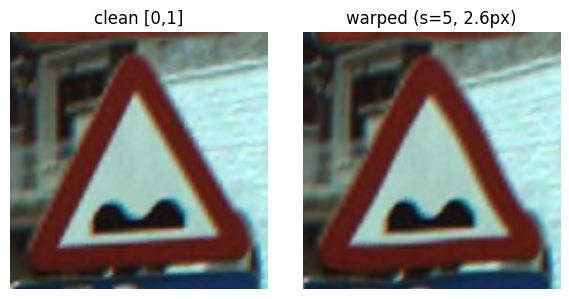

WaNet warp ready (ported). Mean displacement at s=5: 2.55 px.


In [4]:
# ====================================================================================
# WaNet warp — PORTED VERBATIM from VinAIResearch/Warping-based_Backdoor_Attack-release
# train.py lines 343-352 (grid construction) and 199-206 (warp application).
# Authors' originals:
#     ins = torch.rand(1, 2, opt.k, opt.k) * 2 - 1
#     ins = ins / torch.mean(torch.abs(ins))
#     noise_grid = F.upsample(ins, size=opt.input_height, mode='bicubic',
#                             align_corners=True).permute(0, 2, 3, 1)
#     array1d = torch.linspace(-1, 1, steps=opt.input_height)
#     x, y = torch.meshgrid(array1d, array1d)
#     identity_grid = torch.stack((y, x), 2)[None, ...]
#     grid_temps = (identity_grid + opt.s * noise_grid / opt.input_height) * opt.grid_rescale
#     grid_temps = torch.clamp(grid_temps, -1, 1)
#     inputs_bd = F.grid_sample(inputs, grid_temps.repeat(bs,1,1,1), align_corners=True)
# Our ONLY change: seed the control field (WARP_SEED) so it is fixed/reproducible.
# (F.interpolate is the non-deprecated name for the authors' F.upsample — identical op.)
# ====================================================================================
_g = torch.Generator().manual_seed(WARP_SEED)
ins = torch.rand(1, 2, WARP_K, WARP_K, generator=_g) * 2 - 1
ins = ins / torch.mean(torch.abs(ins))                       # normalize -> draw-independent strength
noise_grid = (
    F.interpolate(ins, size=IMG_SIZE, mode='bicubic', align_corners=True)
    .permute(0, 2, 3, 1)
)                                                            # (1, H, W, 2)
array1d = torch.linspace(-1, 1, steps=IMG_SIZE)
x, y = torch.meshgrid(array1d, array1d, indexing='ij')        # 'ij' == authors' default meshgrid
identity_grid = torch.stack((y, x), 2)[None, ...]             # (1, H, W, 2)

def _warp_grid(s):
    # Authors' grid_temps, parameterized by strength s. grid_rescale default = 1.
    grid = (identity_grid + s * noise_grid / IMG_SIZE) * GRID_RESCALE
    return torch.clamp(grid, -1, 1)

def apply_trigger(img01, s):
    # WaNet warp of a [0,1] CHW image at strength s, BEFORE normalize. grid_sample settings
    # are EXACTLY the authors': align_corners=True, default bilinear mode, default 'zeros' pad.
    grid = _warp_grid(s).to(img01.dtype)
    warped = F.grid_sample(img01.unsqueeze(0), grid, align_corners=True)
    return warped.squeeze(0)

def mean_displacement_px(s):
    # Mean L2 pixel displacement grid_sample applies at strength s: (grid - identity) in the
    # [-1,1] normalized frame -> pixels via (IMG_SIZE-1)/2. Directly measures warp magnitude.
    d = (_warp_grid(s) - identity_grid)[0] * (IMG_SIZE - 1) / 2.0   # (H, W, 2) in pixels
    return float(torch.sqrt((d ** 2).sum(-1)).mean().item())

# Quick preview at the Block-A strength.
_img0, _ = test_split[0]
_w0 = apply_trigger(_img0, WARP_S)
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(_img0.permute(1, 2, 0).numpy());            ax[0].set_title('clean [0,1]'); ax[0].axis('off')
ax[1].imshow(_w0.permute(1, 2, 0).clamp(0, 1).numpy());  ax[1].set_title(f'warped (s={WARP_S}, {mean_displacement_px(WARP_S):.1f}px)'); ax[1].axis('off')
plt.tight_layout(); plt.show()
print(f'WaNet warp ready (ported). Mean displacement at s={WARP_S}: {mean_displacement_px(WARP_S):.2f} px.')

## Pre-flight calibration — confirm the subtle `s` range on the REAL ported warp
Warps 3 clean images at every `s` in `WARP_S_GRID` using the actual ported (mean-abs-normalized) warp, annotated with mean pixel displacement. **Eyeball this before the sweep spends GPU** — if the subtle/visible boundary differs from the assumed `s≤0.25`, adjust `WARP_S` / `WARP_S_GRID` in cell 0 and re-run.

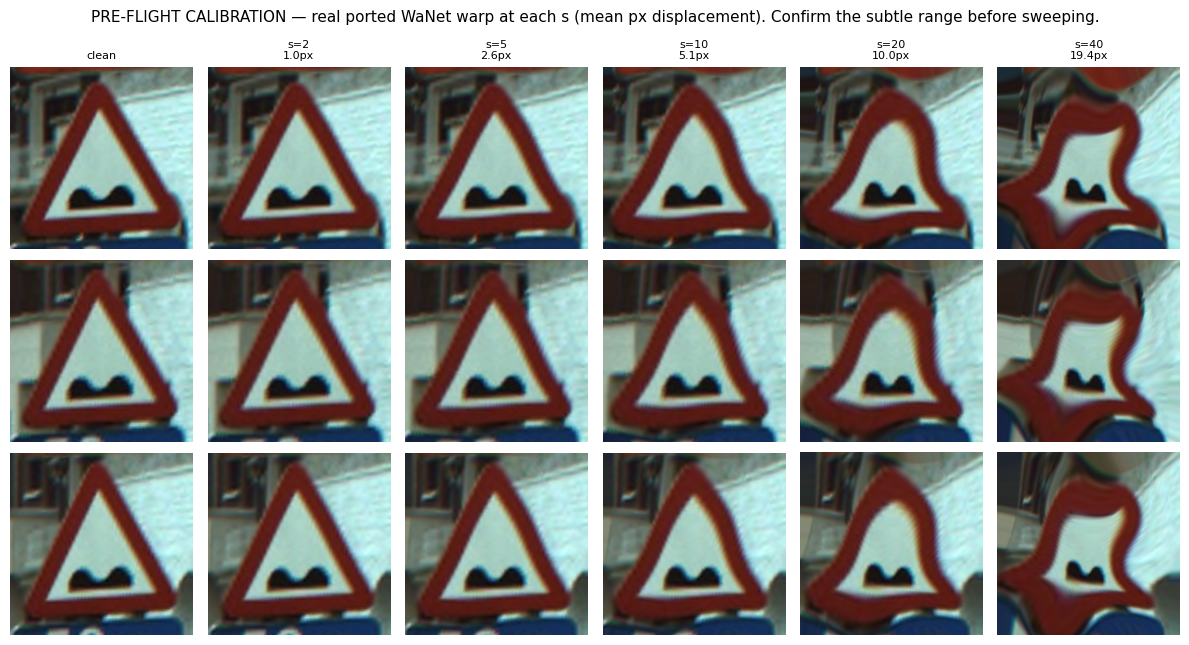

Mean displacement (px) by s: {2: 1.03, 5: 2.55, 10: 5.06, 20: 9.95, 40: 19.4}


In [5]:
cal_idx = [0, 1, 2]
ncols = 1 + len(WARP_S_GRID)
fig, axes = plt.subplots(len(cal_idx), ncols, figsize=(2.0 * ncols, 2.2 * len(cal_idx)))
for row, idx in enumerate(cal_idx):
    img01, _ = test_split[idx]
    axes[row, 0].imshow(img01.permute(1, 2, 0).numpy())
    if row == 0: axes[row, 0].set_title('clean', fontsize=8)
    axes[row, 0].axis('off')
    for col, s in enumerate(WARP_S_GRID, start=1):
        w = apply_trigger(img01, s)
        axes[row, col].imshow(w.permute(1, 2, 0).clamp(0, 1).numpy())
        if row == 0:
            axes[row, col].set_title(f's={s}\n{mean_displacement_px(s):.1f}px', fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('PRE-FLIGHT CALIBRATION — real ported WaNet warp at each s (mean px displacement). '
             'Confirm the subtle range before sweeping.', fontsize=11)
plt.tight_layout(); plt.show()
print('Mean displacement (px) by s:', {s: round(mean_displacement_px(s), 2) for s in WARP_S_GRID})

## Part 2 — Test/val loaders + in-loop noise-mode helpers
WaNet noise mode poisons **per batch in the training loop** (the authors warp on GPU), and the **whole training set participates each batch** via the pc/cross_ratio split — there is no pre-poisoned subset. So the train loader just yields un-normalized `[0,1]` images (`train_split`); the loop (Part 3) does the clean / attack / noise split + normalize. The triggered **test** set scores at `s_train == s_test` using the **fixed attack warp** (no random component).

In [6]:
class NormalizedTestDataset(Dataset):
    """Clean test wrapper: optionally warp (at `s`) EVERY image, then normalize.
    trigger=False -> clean test set (for CA); trigger=True -> fully-warped set (for ASR)."""
    def __init__(self, base_dataset, trigger=False, s=None, normalize_tf=None):
        self.base = base_dataset
        self.trigger = trigger
        self.s = s
        self.normalize = normalize if normalize_tf is None else normalize_tf

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if self.trigger:
            img = apply_trigger(img, self.s)
        return self.normalize(img), label

# Clean test + clean val loaders are strength-independent -> built once.
clean_test_loader = DataLoader(NormalizedTestDataset(test_split, trigger=False),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
val_loader = DataLoader(NormalizedTestDataset(val_split, trigger=False),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

def make_trig_test_loader(s):
    # Fully-warped test set at strength s (fixed attack warp). v1: s_test == s_train.
    return DataLoader(NormalizedTestDataset(test_split, trigger=True, s=s),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# ── In-loop noise-mode helpers (warp on GPU per batch; normalize applied AFTER the warp) ──
_MEAN_D = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
_STD_D  = torch.tensor(IMAGENET_STD,  device=device).view(1, 3, 1, 1)
_identity_grid_d = identity_grid.to(device)
_noise_grid_d    = noise_grid.to(device)

def _attack_grid_d(s):
    # Fixed attack warp grid on device (authors' grid_temps), parameterized by strength s.
    return torch.clamp((_identity_grid_d + s * _noise_grid_d / IMG_SIZE) * GRID_RESCALE, -1, 1)

print('clean/val loaders + make_trig_test_loader(s) + in-loop noise-mode helpers ready.')

clean/val loaders + make_trig_test_loader(s) + in-loop noise-mode helpers ready.


## Model — MobileNetV3-Large (same architecture / freezing / discriminative LRs as the clean notebook)
`build_model()` / `build_optimizer()` are factored so we train a **fresh model from scratch** for each run. For evaluation we rebuild with `pretrained=False` and load the saved state dict.

In [7]:
def build_model(pretrained=True):
    """MobileNetV3-Large: freeze all, unfreeze last 5 feature blocks (12:) + full
    classifier (same as clean training notebook)."""
    weights = MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
    model = models.mobilenet_v3_large(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    for block in model.features[12:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
    return model.to(device)

def build_optimizer(model):
    # Discriminative LRs: features[12:] 2e-5, classifier[0] 5e-5, new head 5e-4
    return torch.optim.Adam([
        {'params': [p for b in model.features[12:] for p in b.parameters()], 'lr': 2e-5},
        {'params': model.classifier[0].parameters(), 'lr': 5e-5},
        {'params': model.classifier[3].parameters(), 'lr': 5e-4},
    ])

print('build_model / build_optimizer ready.')

build_model / build_optimizer ready.


## Part 3 — Training helper (WaNet native noise mode)
`train_one(s, seed)` trains a fresh model with **noise mode applied per batch, the authors' way** (ported from `train.py` 70-89): the **whole shuffled batch** is split — first `int(bs·PC_ATTACK)` images warped→`TARGET_LABEL` (**attack**), next `int(num_bd·PC_NOISE)` warped with an **extra fresh random field** kept at **true** labels (**noise**), the rest **clean**. There is **no dataset-level poison rate** — WaNet poisons per batch. Warp on GPU, then normalize.

Checkpoints: `models/wanet_nm_{model}{CKPT_TAG}_s{s}_seed{seed}.pth` (`nm` = noise mode; no collision with the non-noise family — note: **no `_p{rate}`** anymore). Val stays **clean** for checkpoint selection; ASR eval = fixed attack warp at test `s` (`s_train == s_test`).

In [8]:
def ckpt_path(s, seed):
    return os.path.join(MODELS_DIR, f'wanet_nm_{MODEL_NAME}{CKPT_TAG}_s{s}_seed{seed}.pth')

def resolve_ckpt(s, seed):
    # Reuse if present: models/ first, then legacy cwd. Falls back to the models/ save path.
    # 'nm' tag keeps noise-mode checkpoints from colliding with the non-noise family.
    name = f'wanet_nm_{MODEL_NAME}{CKPT_TAG}_s{s}_seed{seed}.pth'
    for c in (os.path.join(MODELS_DIR, name), name):
        if os.path.exists(c):
            return c
    return os.path.join(MODELS_DIR, name)

def train_one(s, seed=SEED):
    # Native WaNet noise mode: NO dataset poison rate. The whole training set participates; each
    # batch is split clean/attack/noise per pc(=PC_ATTACK)/cross_ratio(=PC_NOISE). `seed` drives
    # init + shuffle order + the per-batch random noise field.
    torch.manual_seed(seed)
    np.random.seed(seed); random.seed(seed)
    train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)   # yields un-normalized [0,1]
    model = build_model(pretrained=True)
    optimizer = build_optimizer(model)
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    criterion = nn.CrossEntropyLoss()
    ckpt = ckpt_path(s, seed)
    attack_grid = _attack_grid_d(s)   # fixed attack warp for this run (on device)
    best_val_acc = 0.0
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        ep_bd = ep_cross = 0
        for imgs01, labels in train_loader:
            imgs01 = imgs01.to(device); labels = labels.to(device)
            # ── WaNet noise-mode per-batch split (ported VERBATIM from train.py 70-89) ──
            # Whole shuffled batch: first num_bd -> attack, next num_cross -> noise, rest clean.
            bs = imgs01.size(0)
            num_bd = int(bs * PC_ATTACK)             # attack: warp -> TARGET (authors' num_bd)
            num_cross = int(num_bd * PC_NOISE)       # noise: warp + random -> true (num_cross)
            x = imgs01.clone()
            labels = labels.clone()
            if num_bd > 0:
                x[:num_bd] = F.grid_sample(imgs01[:num_bd], attack_grid.repeat(num_bd, 1, 1, 1),
                                           align_corners=True)
                labels[:num_bd] = TARGET_LABEL
            if num_cross > 0:
                ins2 = torch.rand(num_cross, IMG_SIZE, IMG_SIZE, 2, device=device) * 2 - 1   # FRESH per batch
                grid2 = torch.clamp(attack_grid.repeat(num_cross, 1, 1, 1) + ins2 / IMG_SIZE, -1, 1)
                x[num_bd:num_bd + num_cross] = F.grid_sample(imgs01[num_bd:num_bd + num_cross], grid2,
                                                             align_corners=True)
            x = (x - _MEAN_D) / _STD_D               # normalize AFTER the warp
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * x.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += x.size(0)
            ep_bd += num_bd; ep_cross += num_cross
        train_loss, train_acc = run_loss / total, correct / total

        model.eval()
        run_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                run_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += imgs.size(0)
        val_loss, val_acc = run_loss / total, correct / total
        scheduler.step()
        saved = val_acc > best_val_acc
        if saved:
            best_val_acc = val_acc
            torch.save(model.state_dict(), ckpt)
        print(f'  [s{s} seed{seed}] Epoch {epoch:02d}/{NUM_EPOCHS} | '
              f'Train Loss {train_loss:.4f} Acc {train_acc:.4f} | '
              f'Val(clean) Loss {val_loss:.4f} Acc {val_acc:.4f} | '
              f'bd/cross per ep {ep_bd}/{ep_cross}'
              + (' *** saved' if saved else ''))
    print(f'  -> best clean-val acc {best_val_acc:.4f}, saved {ckpt}')
    return ckpt

@torch.no_grad()
def evaluate_checkpoint(ckpt, s):
    # CA on the clean test set; ASR on the warped@s test set (s_test == s_train).
    model = build_model(pretrained=False)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    correct, total = 0, 0
    for imgs, labels in clean_test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total += labels.size(0)
    clean_acc = correct / total
    # ASR — exclude true-target images from the denominator (same as BadNets/Blended).
    hit, denom = 0, 0
    for imgs, labels in make_trig_test_loader(s):
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        nontarget = labels != TARGET_LABEL
        hit   += ((preds == TARGET_LABEL) & nontarget).sum().item()
        denom += nontarget.sum().item()
    asr = hit / denom
    return clean_acc, asr

print('train_one / ckpt_path / resolve_ckpt / evaluate_checkpoint ready.')

train_one / ckpt_path / resolve_ckpt / evaluate_checkpoint ready.


## Native-config run — the headline WaNet number (multi-seed)
One WaNet model at the **native operating point** (`s = WARP_S`, noise mode at `pc = PC_ATTACK`, `cross_ratio = PC_NOISE`), trained over seeds `[42, 123, 7]` so the scenario-database entry is a single **CA / ASR mean ± std** per model/dataset. This is WaNet's row in the cross-attack comparison (it has no poison-rate axis, unlike BadNets/Blended).

In [9]:
native_runs = []   # [{'seed', 'clean_acc', 'asr'}]
for seed in SEEDS:
    existing = resolve_ckpt(WARP_S, seed)
    if os.path.exists(existing):
        print(f'\n===== native s{WARP_S} seed{seed} — exists, skipping ({existing}) =====')
        ckpt = existing
    else:
        print(f'\n===== Training native s{WARP_S} seed{seed} (noise mode pc={PC_ATTACK}, cross={PC_NOISE}) =====')
        ckpt = train_one(WARP_S, seed)
    ca, asr = evaluate_checkpoint(ckpt, WARP_S)
    native_runs.append({'seed': seed, 'clean_acc': ca, 'asr': asr})
    print(f'native s{WARP_S} seed{seed}  CA={ca*100:6.2f}%  ASR={asr*100:6.2f}%')

native_ca_mean  = float(np.mean([r['clean_acc'] for r in native_runs]))
native_ca_std   = float(np.std([r['clean_acc'] for r in native_runs]))
native_asr_mean = float(np.mean([r['asr'] for r in native_runs]))
native_asr_std  = float(np.std([r['asr'] for r in native_runs]))
headline_native = (f'WaNet noise mode (s={WARP_S}, pc={PC_ATTACK}) on {MODEL_TITLE} ({DS_TITLE}): '
                   f'CA {native_ca_mean*100:.2f}+/-{native_ca_std*100:.2f}% | '
                   f'ASR {native_asr_mean*100:.2f}+/-{native_asr_std*100:.2f}%  (seeds {SEEDS})')
print('\n' + '=' * 80)
print('HEADLINE:', headline_native)
print('=' * 80)


===== Training native s5 seed42 (noise mode pc=0.1, cross=2.0) =====
  [s5 seed42] Epoch 01/30 | Train Loss 2.9945 Acc 0.3817 | Val(clean) Loss 1.9738 Acc 0.5738 | bd/cross per ep 343/686 *** saved
  [s5 seed42] Epoch 02/30 | Train Loss 1.3857 Acc 0.6541 | Val(clean) Loss 0.9748 Acc 0.7421 | bd/cross per ep 343/686 *** saved
  [s5 seed42] Epoch 03/30 | Train Loss 0.7550 Acc 0.7962 | Val(clean) Loss 0.6226 Acc 0.8328 | bd/cross per ep 343/686 *** saved
  [s5 seed42] Epoch 04/30 | Train Loss 0.4949 Acc 0.8533 | Val(clean) Loss 0.5745 Acc 0.8120 | bd/cross per ep 343/686
  [s5 seed42] Epoch 05/30 | Train Loss 0.3879 Acc 0.8831 | Val(clean) Loss 0.4823 Acc 0.8383 | bd/cross per ep 343/686 *** saved
  [s5 seed42] Epoch 06/30 | Train Loss 0.2942 Acc 0.9068 | Val(clean) Loss 0.4613 Acc 0.8404 | bd/cross per ep 343/686 *** saved
  [s5 seed42] Epoch 07/30 | Train Loss 0.2353 Acc 0.9309 | Val(clean) Loss 0.4700 Acc 0.8219 | bd/cross per ep 343/686
  [s5 seed42] Epoch 08/30 | Train Loss 0.2065 A

## Perceptual metrics setup (PSNR / SSIM / LPIPS + mean displacement)
PSNR/SSIM/LPIPS reused verbatim from BadNets/Blended (same libs, thresholds PSNR > 30, SSIM > 0.95, LPIPS < 0.1, same `METRIC_N`), computed clean-vs-warped in `[0,1]` space. **Plus** the warp-native **mean pixel displacement** (Part 7 explains why additive metrics under-report a warp).

In [10]:
import subprocess, sys, math
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lpips', 'scikit-image', '-q'], check=True)
import lpips
from skimage.metrics import structural_similarity as ssim_fn

METRIC_N = 500   # number of test images to measure over (same as BadNets/Blended)
lpips_fn = lpips.LPIPS(net='alex').to(device)

def _psnr01(a, b):
    mse = ((a - b) ** 2).mean()
    return 10 * math.log10(1.0 / mse) if mse > 0 else float('inf')

_metric_rng = random.Random(SEED)
metric_idx = _metric_rng.sample(range(len(test_split)), min(METRIC_N, len(test_split)))

def perceptual_at_s(s):
    """Mean PSNR/SSIM/LPIPS (clean vs warped@s) over the fixed sample, + mean px displacement."""
    psnrs, ssims, lpips_vals = [], [], []
    with torch.no_grad():
        for idx in metric_idx:
            img01, _ = test_split[idx]              # [0,1] CHW
            w01 = apply_trigger(img01, s).clamp(0, 1)
            o = img01.permute(1, 2, 0).numpy()
            a = w01.permute(1, 2, 0).numpy()
            psnrs.append(_psnr01(o, a))
            ssims.append(ssim_fn(o, a, channel_axis=2, data_range=1.0))
            o11 = (img01.unsqueeze(0).to(device) * 2 - 1)   # LPIPS expects [-1,1]
            a11 = (w01.unsqueeze(0).to(device)   * 2 - 1)
            lpips_vals.append(lpips_fn(o11, a11).item())
    finite = [p for p in psnrs if math.isfinite(p)]
    return (float(np.mean(finite)), float(np.mean(ssims)), float(np.mean(lpips_vals)),
            mean_displacement_px(s))
print(f'Perceptual setup ready (METRIC_N={METRIC_N}).')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lpips\weights\v0.1\alex.pth
Perceptual setup ready (METRIC_N=500).


## Block B — strength (`s`) sweep at the native pc
Iterate `WARP_S_GRID` (noise mode at `pc = PC_ATTACK`, `cross_ratio = PC_NOISE`), **single seed** (`SEED`) for v1. Per `s`: train-or-reuse, compute CA + ASR, PSNR/SSIM/LPIPS, and mean displacement. This is WaNet's stealth-vs-potency curve for the database.

> **Note:** the low-`s` end (2, 5) is the marginal regime where — per our recurring seed-variance lesson — a single seed may be unreliable. Multi-seed the low-`s` end if Block B looks noisy (a v1.5 fix). The `s=WARP_S` seed-42 checkpoint here is the SAME file as the native-config seed-42 run (reused, not retrained).

In [11]:
strength_checkpoints = {}
for s in WARP_S_GRID:
    existing = resolve_ckpt(s, SEED)
    if os.path.exists(existing):
        print(f'\n===== B s{s} seed{SEED} — exists, skipping ({existing}) =====')
        strength_checkpoints[s] = existing
        continue
    print(f'\n===== Training B s{s} seed{SEED} (noise mode pc={PC_ATTACK}, cross={PC_NOISE}) =====')
    strength_checkpoints[s] = train_one(s, SEED)
print('\nBlock B trainings done:', len(strength_checkpoints), 'checkpoints')


===== Training B s2 seed42 (noise mode pc=0.1, cross=2.0) =====
  [s2 seed42] Epoch 01/30 | Train Loss 2.9917 Acc 0.3792 | Val(clean) Loss 1.9942 Acc 0.5541 | bd/cross per ep 343/686 *** saved
  [s2 seed42] Epoch 02/30 | Train Loss 1.3939 Acc 0.6555 | Val(clean) Loss 1.0303 Acc 0.7104 | bd/cross per ep 343/686 *** saved
  [s2 seed42] Epoch 03/30 | Train Loss 0.7678 Acc 0.7863 | Val(clean) Loss 0.6903 Acc 0.8066 | bd/cross per ep 343/686 *** saved
  [s2 seed42] Epoch 04/30 | Train Loss 0.5176 Acc 0.8462 | Val(clean) Loss 0.6625 Acc 0.7639 | bd/cross per ep 343/686
  [s2 seed42] Epoch 05/30 | Train Loss 0.4005 Acc 0.8705 | Val(clean) Loss 0.5831 Acc 0.7847 | bd/cross per ep 343/686
  [s2 seed42] Epoch 06/30 | Train Loss 0.3113 Acc 0.8978 | Val(clean) Loss 0.5313 Acc 0.8077 | bd/cross per ep 343/686 *** saved
  [s2 seed42] Epoch 07/30 | Train Loss 0.2436 Acc 0.9276 | Val(clean) Loss 0.4797 Acc 0.8197 | bd/cross per ep 343/686 *** saved
  [s2 seed42] Epoch 08/30 | Train Loss 0.2061 Acc 0.

In [12]:
if 'strength_checkpoints' not in dir():
    strength_checkpoints = {s: resolve_ckpt(s, SEED) for s in WARP_S_GRID}

strength_results = {}   # s -> {clean_acc, asr, psnr, ssim, lpips, disp_px}
print(f'{MODEL_TITLE} — WaNet noise mode strength sweep (pc={PC_ATTACK}) on {DS_TITLE}')
print('s     | Clean Acc | ASR     | PSNR(dB) | SSIM   | LPIPS  | disp(px)')
print('-' * 78)
for s in WARP_S_GRID:
    ca, asr = evaluate_checkpoint(strength_checkpoints[s], s)
    psnr, ssim, lp, disp = perceptual_at_s(s)
    strength_results[s] = {'clean_acc': ca, 'asr': asr, 'psnr': psnr, 'ssim': ssim,
                           'lpips': lp, 'disp_px': disp}
    print(f'{s:<5} | {ca*100:7.2f}% | {asr*100:6.2f}% | {psnr:7.2f}  | {ssim:.4f} | {lp:.4f} | {disp:6.2f}')

MobileNetV3-Large — WaNet noise mode strength sweep (pc=0.1) on BelgiumTSC
s     | Clean Acc | ASR     | PSNR(dB) | SSIM   | LPIPS  | disp(px)
------------------------------------------------------------------------------
2     |   84.60% |  27.76% |   33.27  | 0.9627 | 0.0115 |   1.03
5     |   85.36% |  62.37% |   26.03  | 0.8630 | 0.0382 |   2.55
10    |   92.42% |  96.82% |   21.17  | 0.7281 | 0.0975 |   5.06
20    |   95.32% |  99.68% |   17.18  | 0.5788 | 0.2336 |   9.95
40    |   96.35% | 100.00% |   14.22  | 0.4599 | 0.4324 |  19.40


### Block B — the "money plot": stealth vs potency
x = warp strength `s`; LEFT y = ASR (potency); RIGHT y = SSIM & LPIPS (stealth). Saved as `mobilenetv3_wanet_bel_strength_sweep.png`.

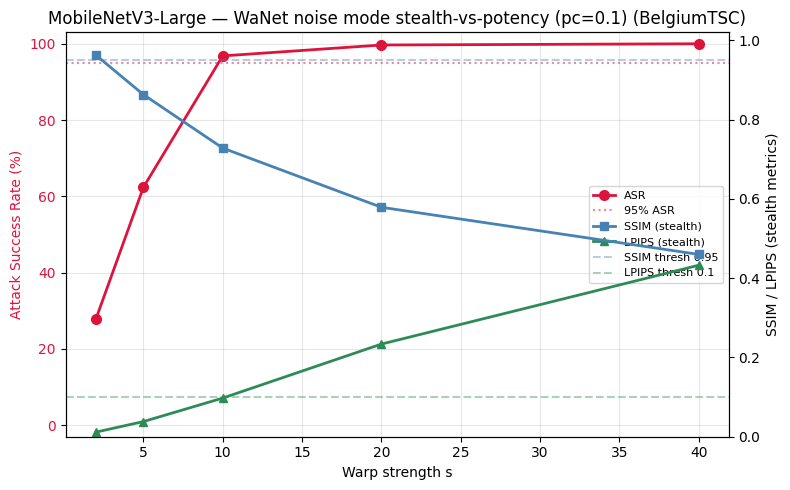

Saved mobilenetv3_wanet_nm_bel_strength_sweep.png


In [13]:
ss      = list(WARP_S_GRID)
asr_b   = [strength_results[s]['asr'] * 100 for s in ss]
ssim_b  = [strength_results[s]['ssim'] for s in ss]
lpips_b = [strength_results[s]['lpips'] for s in ss]

fig, ax1 = plt.subplots(figsize=(8, 5))
c_asr, c_ssim, c_lpips = 'crimson', 'steelblue', 'seagreen'
ax1.plot(ss, asr_b, 'o-', color=c_asr, linewidth=2, markersize=7, label='ASR')
ax1.axhline(95, color=c_asr, linestyle=':', alpha=0.5, label='95% ASR')
ax1.set_xlabel('Warp strength s')
ax1.set_ylabel('Attack Success Rate (%)', color=c_asr)
ax1.tick_params(axis='y', labelcolor=c_asr)
ax1.set_ylim(-3, 103)
ax2 = ax1.twinx()
ax2.plot(ss, ssim_b,  's-', color=c_ssim,  linewidth=2, markersize=6, label='SSIM (stealth)')
ax2.plot(ss, lpips_b, '^-', color=c_lpips, linewidth=2, markersize=6, label='LPIPS (stealth)')
ax2.axhline(0.95, color=c_ssim,  linestyle='--', alpha=0.4, label='SSIM thresh 0.95')
ax2.axhline(0.10, color=c_lpips, linestyle='--', alpha=0.4, label='LPIPS thresh 0.1')
ax2.set_ylabel('SSIM / LPIPS (stealth metrics)')
ax2.set_ylim(0, 1.02)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)
plt.title(f'{MODEL_TITLE} — WaNet noise mode stealth-vs-potency (pc={PC_ATTACK}) ({DS_TITLE})')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_wanet_nm_{DS_SHORT}_strength_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {MODEL_NAME}_wanet_nm_{DS_SHORT}_strength_sweep.png')

## Part 7 — Perceptual framing (why a warp needs a displacement metric)
PSNR, SSIM and LPIPS are built for **additive** perturbations — they compare pixel *values* at fixed locations. A warp **moves** pixels rather than changing their values, so a perceptually obvious geometric distortion can leave these value-comparison metrics relatively high — i.e. they may **under-report** a warp's visibility. We therefore also report **mean pixel displacement**, which directly measures warp magnitude.

**Methodological contrast across the benchmark's three triggers:**
- **BadNets** (Gu et al. 2017): *localized additive* — fails PSNR, passes SSIM/LPIPS (a tiny patch barely moves global averages).
- **Blended** (Chen et al. 2017): *global additive* — SSIM/LPIPS are the appropriate stealth metrics (whole-image value change).
- **WaNet** (Nguyen & Tran 2021): *global structural* (a warp) — standard additive perceptual metrics are arguably the **wrong tool**; mean displacement is the honest measure. This three-way split is itself a benchmark observation, not an afterthought.

## Scope — noise mode is WaNet's fair operating configuration (default here)
This notebook trains **noise mode** as the default and only mode: each batch is split clean / attack(warp→target) / noise(warp+extra-random→true-label) in the training loop (the `noise` set is warped with the fixed attack field **plus a fresh random field per batch**, kept at its true label). Noise mode is WaNet's fair config — it both **hardens against trigger-reversal defenses** (Neural Cleanse etc.: the model learns to fire only on the *exact* warp field, not any warp) **and sharpens trigger learning**.

The earlier **non-noise (plain) WaNet** result is **retained separately** (different checkpoint family `wanet_…`, this one is `wanet_nm_…`) for the planned **noise-vs-no-noise** comparison and the defense-phase experiment (*plain WaNet vs Neural Cleanse* against *WaNet+noise-mode vs Neural Cleanse*).

## Visualization — clean vs warped across ALL strengths
Rows = sample non-target test images. Columns = clean (true label), then the image warped at every `s` in `WARP_S_GRID`. Each warped cell shows its `s` and the prediction of that `s`'s **Block-B backdoor model** (native pc); red `*` = flipped to the target class.

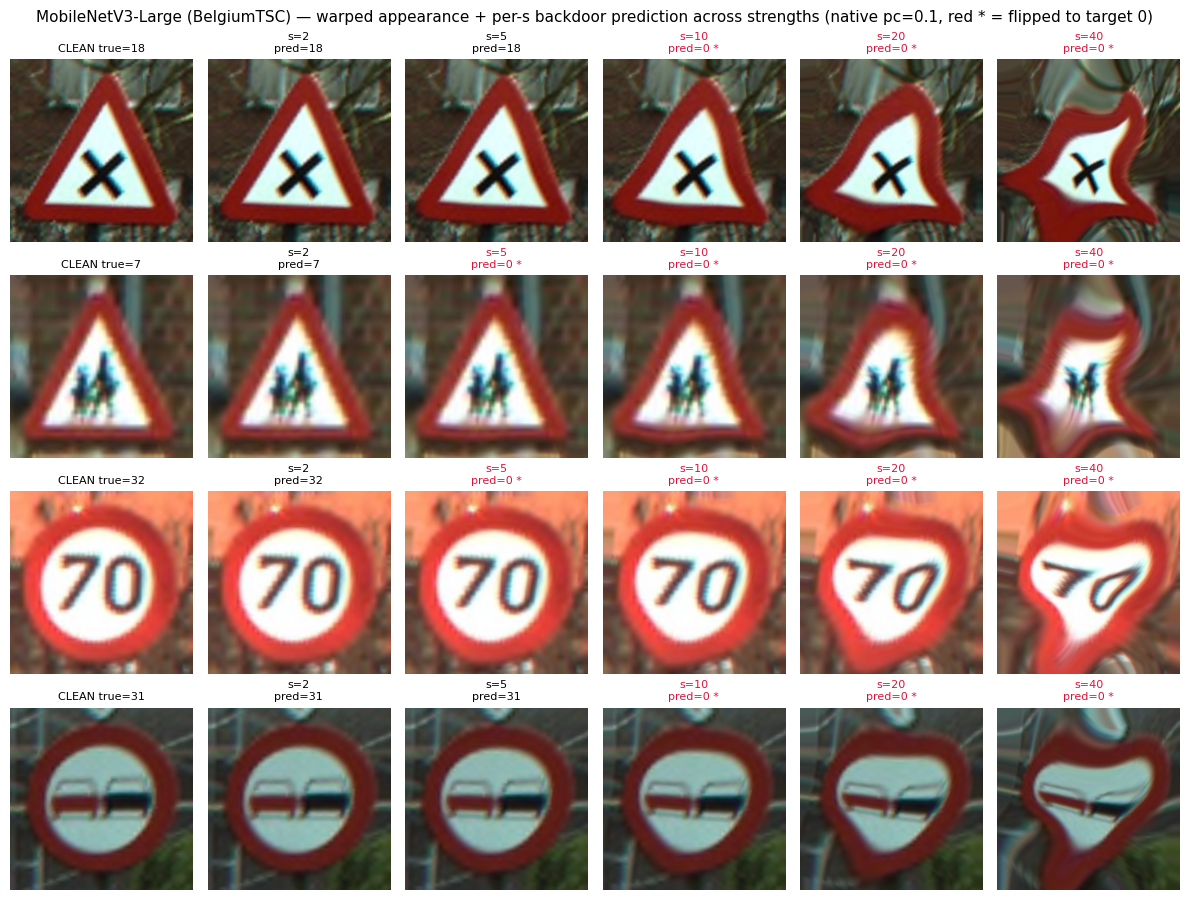

In [14]:
s_models = {}
for s in WARP_S_GRID:
    m = build_model(pretrained=False)
    m.load_state_dict(torch.load(strength_checkpoints[s], map_location=device)); m.eval()
    s_models[s] = m

rng = random.Random(SEED)
cand = [i for i in range(len(test_split)) if test_split[i][1] != TARGET_LABEL]
show_idx = rng.sample(cand, 4)

ncols = 1 + len(WARP_S_GRID)
fig, axes = plt.subplots(len(show_idx), ncols, figsize=(2.0 * ncols, 2.3 * len(show_idx)))
with torch.no_grad():
    for row, idx in enumerate(show_idx):
        img01, true_label = test_split[idx]
        ax = axes[row, 0]
        ax.imshow(img01.permute(1, 2, 0).numpy())
        ax.set_title(f'CLEAN true={true_label}', fontsize=8)
        ax.axis('off')
        for col, s in enumerate(WARP_S_GRID, start=1):
            w01 = apply_trigger(img01, s).clamp(0, 1)
            pred = s_models[s](normalize(w01).unsqueeze(0).to(device)).argmax(1).item()
            flipped = pred == TARGET_LABEL
            ax = axes[row, col]
            ax.imshow(w01.permute(1, 2, 0).numpy())
            ax.set_title(f's={s}\npred={pred}' + (' *' if flipped else ''),
                         fontsize=8, color=('crimson' if flipped else 'black'))
            ax.axis('off')
plt.suptitle(f'{MODEL_TITLE} ({DS_TITLE}) — warped appearance + per-s backdoor prediction across strengths '
             f'(native pc={PC_ATTACK}, red * = flipped to target {TARGET_LABEL})', fontsize=11)
plt.tight_layout()
plt.show()

## Part 8 — Summary + JSON dump
Dumps the native-config headline (CA/ASR mean±std) and Block B (strength sweep, incl. displacement-per-s) plus full config to `wanet_nm_mobilenetv3_bel.json` for cross-attack aggregation.

In [15]:
print('=' * 80)
print('HEADLINE (native config):', headline_native)
s_hits = [s for s in WARP_S_GRID if strength_results[s]['asr'] >= 0.95]
min_s_95 = min(s_hits) if s_hits else None
if min_s_95 is not None:
    r = strength_results[min_s_95]
    print(f'HEADLINE (B, strength floor): >=95% ASR from s={min_s_95} '
          f'(SSIM={r["ssim"]:.3f}, LPIPS={r["lpips"]:.3f}, disp={r["disp_px"]:.2f}px).')
else:
    print(f'HEADLINE (B): no s in {WARP_S_GRID} reached >=95% ASR at the native pc.')
print('=' * 80)

out = {
    'model': MODEL_NAME,
    'dataset': DS_SHORT,
    'attack': 'wanet_noise_mode',
    'reference': 'Nguyen & Tran 2021, ICLR (WaNet: Imperceptible Warping-based Backdoor Attack)',
    'warp_ported_from': 'VinAIResearch/Warping-based_Backdoor_Attack-release (train.py)',
    'target_label': TARGET_LABEL,
    'trigger': {'type': 'wanet warp (grid_sample)', 'warp_seed': WARP_SEED, 'warp_k': WARP_K,
                'img_size': IMG_SIZE, 'grid_rescale': GRID_RESCALE,
                'grid_sample': 'align_corners=True, bilinear, zeros-pad (authors settings)',
                'space': '[0,1] pixel space, applied before normalization',
                's_train_eq_s_test': True},
    'noise_mode': {'enabled': True, 'pc_attack': PC_ATTACK, 'cross_ratio': PC_NOISE,
                   'application': 'per-batch in training loop (authors train.py 70-89); whole batch',
                   'no_dataset_poison_rate': 'WaNet poisons per batch; no POISON_RATES sweep (native config).'},
    'num_epochs': NUM_EPOCHS, 'batch_size': BATCH_SIZE, 'num_classes': NUM_CLASSES,
    'seed': SEED, 'seeds': SEEDS,
    'warp_s': WARP_S, 'warp_s_grid': list(WARP_S_GRID),
    # ── Native-config headline: (s=WARP_S, native pc), multi-seed mean±std ──
    'native_config': {
        's': WARP_S, 'pc_attack': PC_ATTACK, 'cross_ratio': PC_NOISE,
        'runs': native_runs,
        'clean_acc_mean': native_ca_mean, 'clean_acc_std': native_ca_std,
        'asr_mean': native_asr_mean, 'asr_std': native_asr_std,
        'headline': headline_native,
    },
    # ── Block B: strength sweep at the native pc (single seed) ──
    'block_b': {
        'pc_attack': PC_ATTACK, 'cross_ratio': PC_NOISE,
        'strength_results': {str(s): strength_results[s] for s in WARP_S_GRID},
        'displacement_px': {str(s): mean_displacement_px(s) for s in WARP_S_GRID},
        'min_s_95asr': min_s_95,
    },
    # ── Block C: stubbed in v1 ──
    'block_c': 'stub (not implemented in v1; see block_c_2d_grid_PLACEHOLDER)',
}
json_path = f'wanet_nm_{MODEL_NAME}_{DS_SHORT}.json'
with open(json_path, 'w') as f:
    json.dump(out, f, indent=2)
print(f'Saved {json_path}')

HEADLINE (native config): WaNet noise mode (s=5, pc=0.1) on MobileNetV3-Large (BelgiumTSC): CA 84.99+/-1.71% | ASR 57.78+/-3.28%  (seeds [42, 123, 7])
HEADLINE (B, strength floor): >=95% ASR from s=10 (SSIM=0.728, LPIPS=0.097, disp=5.06px).
Saved wanet_nm_mobilenetv3_bel.json


## Block C — 2-D `s` × `pc` floor grid (STUB, not implemented in v1)
Future work: a focused 2-D grid over warp strength `s` × per-batch poison fraction `pc` → an ASR heatmap. (WaNet has no dataset poison rate, so the second axis is `pc`, not a dataset fraction.) Left as a stub in v1.

In [16]:
def block_c_2d_grid_PLACEHOLDER():
    pass
# v2 EXTENSION POINT (do not implement in v1): a focused 2-D grid over
# (s in a low-strength subset) x (pc in {0.01, 0.05, 0.1, ...}). For each (s, pc) cell, train with
# the per-batch noise-mode split at that pc and record ASR -> a 2-D ASR heatmap (rows=s, cols=pc),
# seed-averaged in the marginal corner. Captures the s x pc INTERACTION that the native-config
# point + the 1-D s-sweep cannot, and locates joint (s, pc) operating points.